<a href="https://colab.research.google.com/github/mars8577/CSC.htm/blob/main/Project_1_data_house1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
from google.colab import files

uploaded = files.upload()

Saving kc_house_data.csv.xlsx to kc_house_data.csv (2).xlsx


In [6]:
import pandas as pd
import numpy as np
import plotly.express as px
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.stats.multicomp as multi
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols


df = pd.read_csv("kc_house_data (1).csv")
df.head()
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [56]:
import pandas as pd

columns = [
    'id', 'date', 'price', 'bedrooms', 'bathrooms',
    'sqft_living', 'sqft_lot', 'floors', 'waterfront',
    'view', 'condition', 'grade', 'sqft_above',
    'sqft_basement', 'yr_built', 'yr_renovated',
    'zipcode', 'lat', 'long'
]

df = pd.read_csv(
"kc_house_data (1).csv",
    sep='\t',
    header=None,
    names=columns
)

print(df.head())

                                                  id  date  price  bedrooms  \
0  id,date,price,bedrooms,bathrooms,sqft_living,s...   NaN    NaN       NaN   
1  7129300520,20141013T000000,221900,3,1,1180,565...   NaN    NaN       NaN   
2  6414100192,20141209T000000,538000,3,2.25,2570,...   NaN    NaN       NaN   
3  5631500400,20150225T000000,180000,2,1,770,1000...   NaN    NaN       NaN   
4  2487200875,20141209T000000,604000,4,3,1960,500...   NaN    NaN       NaN   

   bathrooms  sqft_living  sqft_lot  floors  waterfront  view  condition  \
0        NaN          NaN       NaN     NaN         NaN   NaN        NaN   
1        NaN          NaN       NaN     NaN         NaN   NaN        NaN   
2        NaN          NaN       NaN     NaN         NaN   NaN        NaN   
3        NaN          NaN       NaN     NaN         NaN   NaN        NaN   
4        NaN          NaN       NaN     NaN         NaN   NaN        NaN   

   grade  sqft_above  sqft_basement  yr_built  yr_renovated  zipcode

In [7]:
df.head()
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [8]:
df.shape
df


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [9]:
df.info
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [10]:
df.describe
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [11]:
df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


In [12]:
df.duplicated().sum()


np.int64(0)

In [13]:
df = df.drop_duplicates()
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [14]:
df.fillna(df.mean(numeric_only=True),inplace=True)
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [15]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [16]:
df['price'].head()


,price
0,221900.0
1,538000.0
2,180000.0
3,604000.0
4,510000.0


In [17]:
df['price'].describe()

,price
count,2.161300e+04
mean,5.401822e+05
std,3.673622e+05
min,7.500000e+04
25%,3.219500e+05
50%,4.500000e+05
75%,6.450000e+05
max,7.700000e+06


In [18]:
df.columns
df['bedrooms'].head()


,bedrooms
0,3
1,3
2,2
3,4
4,3


In [19]:
df['bedrooms'].describe()

,bedrooms
count,21613.000000
mean,3.370842
std,0.930062
min,0.000000
25%,3.000000
50%,3.000000
75%,4.000000
max,33.000000


In [20]:
df[['bedrooms', 'bathrooms', 'price']].head()

,bedrooms,bathrooms,price
0,3,1.00,221900.0
1,3,2.25,538000.0
2,2,1.00,180000.0
3,4,3.00,604000.0
4,3,2.00,510000.0


In [21]:
df[['bedrooms','sqft_living']].head()


,bedrooms,sqft_living
0,3,1180
1,3,2570
2,2,770
3,4,1960
4,3,1680


In [22]:
df[['bathrooms', 'sqft_living']].head()

,bathrooms,sqft_living
0,1.00,1180
1,2.25,2570
2,1.00,770
3,3.00,1960
4,2.00,1680


In [23]:
df.tail()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287
21612,1523300157,20141015T000000,325000.0,2,0.75,1020,1076,2.0,0,0,...,7,1020,0,2008,0,98144,47.5941,-122.299,1020,1357


In [24]:

df['sqft_lot'].head()

,sqft_lot
0,5650
1,7242
2,10000
3,5000
4,8080


In [25]:
df['floors'].head()

,floors
0,1.0
1,2.0
2,1.0
3,1.0
4,1.0


In [26]:
df['waterfront'].head()

,waterfront
0,0
1,0
2,0
3,0
4,0


In [27]:
df[['condition','grade','yr_built','yr_renovated']].head()

,condition,grade,yr_built,yr_renovated
0,3,7,1955,0
1,3,7,1951,1991
2,3,6,1933,0
3,5,7,1965,0
4,3,8,1987,0


In [28]:
df[['lat','long','zipcode']].head()

,lat,long,zipcode
0,47.5112,-122.257,98178
1,47.7210,-122.319,98125
2,47.7379,-122.233,98028
3,47.5208,-122.393,98136
4,47.6168,-122.045,98074


In [29]:
y = df['price']
X = df.drop('price', axis=1)

X.head()
y.head()

,price
0,221900.0
1,538000.0
2,180000.0
3,604000.0
4,510000.0


In [30]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, chi2
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split


np.random.seed(42)

df = pd.DataFrame({
    'bedrooms': np.random.randint(1, 6, 100),
    'bathrooms': np.random.randint(1, 5, 100),
    'sqft_living': np.random.randint(500, 5000, 100),
})

df['price'] = (
    50000
    + df['bedrooms'] * 30000
    + df['bathrooms'] * 20000
    + df['sqft_living'] * 150
    + np.random.randint(-50000, 50000, 100)
)

df.head()

,bedrooms,bathrooms,sqft_living,price
0,4,4,4913,959349
1,5,3,4248,893414
2,3,1,1163,383972
3,5,4,2498,691116
4,5,4,3945,892021


In [31]:


# Synthetic dataset
np.random.seed(42)

sqft_living = np.random.randint(500, 5000, 100)
sqft_living[:5]

array([1360, 4272, 3592,  966, 4926])

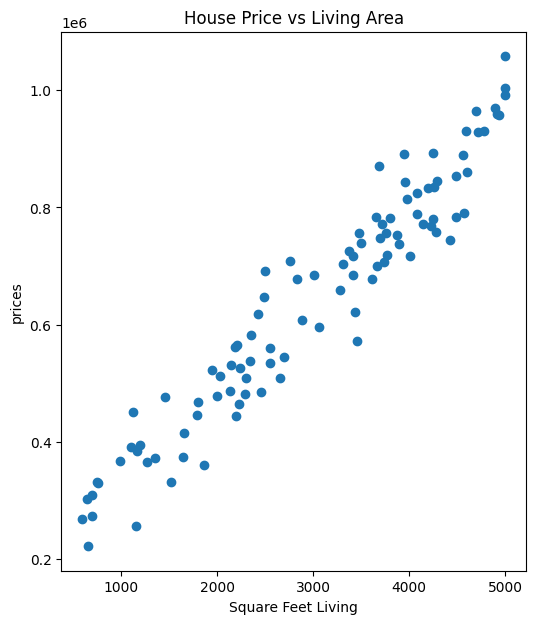

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 7))
plt.scatter(df['sqft_living'], df['price'])

plt.xlabel('Square Feet Living')
plt.ylabel('prices')
plt.title('House Price vs Living Area')
plt.show()

In [33]:
y = df['price']
X = df.drop('price', axis=1)
df.head()
df.head()

,bedrooms,bathrooms,sqft_living,price
0,4,4,4913,959349
1,5,3,4248,893414
2,3,1,1163,383972
3,5,4,2498,691116
4,5,4,3945,892021


In [34]:
X = X.select_dtypes(include=['int64', 'float64'])
print(X.head())

   bedrooms  bathrooms  sqft_living
0         4          4         4913
1         5          3         4248
2         3          1         1163
3         5          4         2498
4         5          4         3945


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
 )
print(X_train)
print(y_train)
print(X_test)
print(y_test)


    bedrooms  bathrooms  sqft_living
15         2          4         3499
40         4          3         4782
96         5          3         4993
9          5          3         2353
72         5          4         2755
..       ...        ...          ...
60         2          3         3869
71         5          2         2182
14         4          4         4196
92         3          1         4291
51         4          3         2234

[75 rows x 3 columns]
15    739140
40    929935
96    991047
9     582780
72    709570
       ...  
60    752235
71    562317
14    832836
92    844733
51    525592
Name: price, Length: 75, dtype: int64
    bedrooms  bathrooms  sqft_living
83         5          4         3683
53         5          1          988
70         1          1         3670
45         1          4         3311
44         2          1         1159
39         2          1         1647
22         4          3         2207
80         5          4         4699
10         4       

In [36]:
linear = LinearRegression()
linear.fit(X_train, y_train)
linear_pred = linear.predict(X_test)

print(LinearRegression())
print(linear_pred)


LinearRegression()
[827899.55638549 355049.88457637 651375.19759957 664605.80604316
 300303.40237446 373746.13417616 556518.48773261 980804.9160382
 471491.84365762 986184.18063115 544212.27267841 365653.52873938
 442058.79147102 615406.31870489 704569.28869443 867329.87550853
 496801.20366839 877834.82698667 801876.6688371  960152.51783948
 513962.29503058 921934.95316957 258353.2692819  699938.12348601
 564202.63043877]


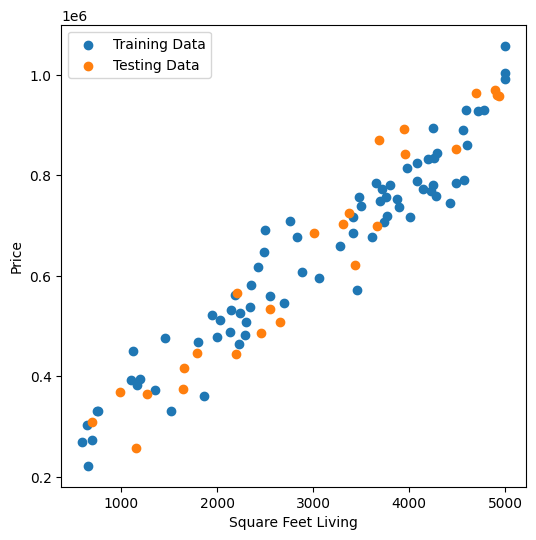

In [37]:
plt.figure(figsize=(6,6))

plt.scatter(X_train['sqft_living'], y_train, label='Training Data')
plt.scatter(X_test['sqft_living'], y_test, label='Testing Data')

plt.xlabel('Square Feet Living')
plt.ylabel('Price')
plt.legend()

plt.show()

In [38]:
print(type(X_train))
print(X_train.shape)

<class 'pandas.core.frame.DataFrame'>
(75, 3)


In [39]:
linear_pred = linear.predict(X_test)

r2_score(y_test, linear_pred)
mean_absolute_error(y_test, linear_pred)

26666.36226605622

In [40]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [41]:
X_train[:5]

,bedrooms,bathrooms,sqft_living
15,2,4,3499
40,4,3,4782
96,5,3,4993
9,5,3,2353
72,5,4,2755


In [42]:
y_train.head()

,price
15,739140
40,929935
96,991047
9,582780
72,709570


In [43]:
y_pred = lr.predict(X_test)
y_pred[:5]

array([827899.55638549, 355049.88457637, 651375.19759957, 664605.80604316,
       300303.40237446])

In [44]:
comparison = pd.DataFrame({
    'Actual Price': y_test[:5].values,
    'Predicted Price': y_pred[:5]
})

comparison

,Actual Price,Predicted Price
0,871341,827899.556385
1,368536,355049.884576
2,700213,651375.197600
3,703402,664605.806043
4,257270,300303.402374


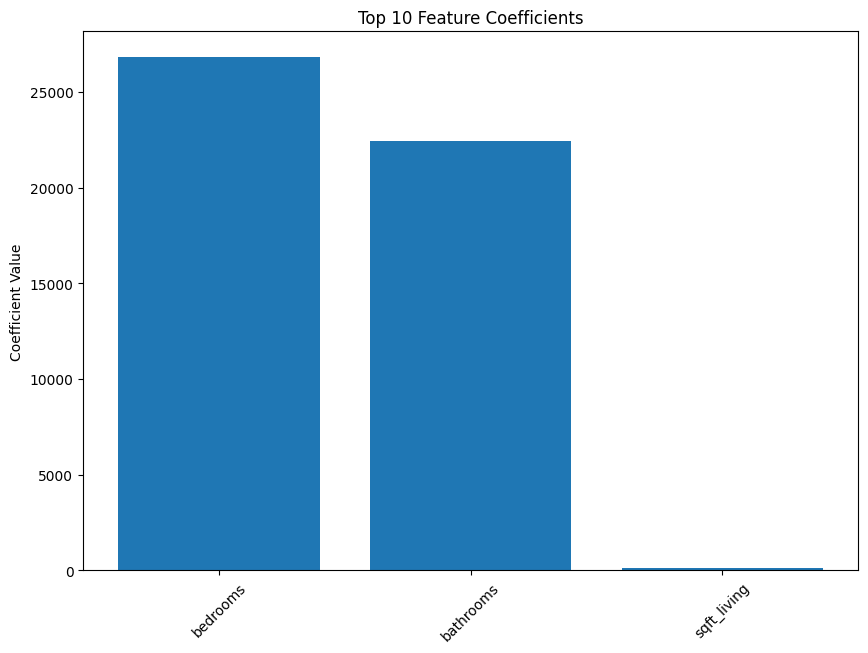

In [45]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
})

coef_df = coef_df.sort_values('Coefficient', ascending=False).head(10)

plt.figure(figsize=(10,7))
plt.bar(coef_df['Feature'], coef_df['Coefficient'])
plt.xticks(rotation=45)
plt.title('Top 10 Feature Coefficients')
plt.ylabel('Coefficient Value')
plt.show()

In [46]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
})

coef_df.sort_values('Coefficient', ascending=False)

,Feature,Coefficient
0,bedrooms,26827.179271
1,bathrooms,22419.725162
2,sqft_living,150.497401


In [47]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)
lasso_pred[:5]

array([827897.31234106, 355050.42603987, 651377.50004728, 664605.5509399 ,
       300305.4019549 ])

In [48]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.linear_model import Ridge

def evaluate(name, y_true, y_pred):
    print(f"\n{name}")
    print("R² =", r2_score(y_true, y_pred))
    print("MAE =", mean_absolute_error(y_true, y_pred))
    print("RMSE =", np.sqrt(mean_squared_error(y_true, y_pred)))

# Ridge Regression
ridge = Ridge(alpha=1.0)  # You can tune the alpha parameter
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

evaluate("Linear Regression", y_test, linear_pred)
evaluate("Ridge Regression", y_test, ridge_pred)
evaluate("Lasso Regression", y_test, lasso_pred)


Linear Regression
R² = 0.9818541699927834
MAE = 26666.36226605622
RMSE = 30666.41331376553

Ridge Regression
R² = 0.9818572754375694
MAE = 26628.41564037637
RMSE = 30663.789104012176

Lasso Regression
R² = 0.9818542415644362
MAE = 26666.178805355812
RMSE = 30666.352835736907


In [49]:
linear_pred
ridge_pred
lasso_pred

array([827897.31234106, 355050.42603987, 651377.50004728, 664605.5509399 ,
       300305.4019549 , 373748.09733125, 556517.70560266, 980802.5961574 ,
       471491.95402793, 986182.33507051, 544212.92761631, 365654.16859038,
       442058.16975613, 615408.63899205, 704568.91012393, 867327.61190787,
       496801.03179106, 877834.73582333, 801876.98868822, 960151.53551942,
       513962.96497154, 921935.69046359, 258354.8126802 , 699936.41989465,
       564203.54515705])

In [50]:
from sklearn.linear_model import LinearRegression

linear = LinearRegression()
linear.fit(X_train, y_train)
linear_pred = linear.predict(X_test)

print(LinearRegression)
print(linear_pred)

<class 'sklearn.linear_model._base.LinearRegression'>
[827899.55638549 355049.88457637 651375.19759957 664605.80604316
 300303.40237446 373746.13417616 556518.48773261 980804.9160382
 471491.84365762 986184.18063115 544212.27267841 365653.52873938
 442058.79147102 615406.31870489 704569.28869443 867329.87550853
 496801.20366839 877834.82698667 801876.6688371  960152.51783948
 513962.29503058 921934.95316957 258353.2692819  699938.12348601
 564202.63043877]


Why This Matters

Data Exploration
Summary statistics, distributions, correlations.

In [51]:
corr = df.corr(numeric_only = True)
corr['price'].sort_values(ascending=False)
corr

,bedrooms,bathrooms,sqft_living,price
bedrooms,1.000000,0.072586,0.026066,0.226492
bathrooms,0.072586,1.000000,0.052164,0.175133
sqft_living,0.026066,0.052164,1.000000,0.962880
price,0.226492,0.175133,0.962880,1.000000


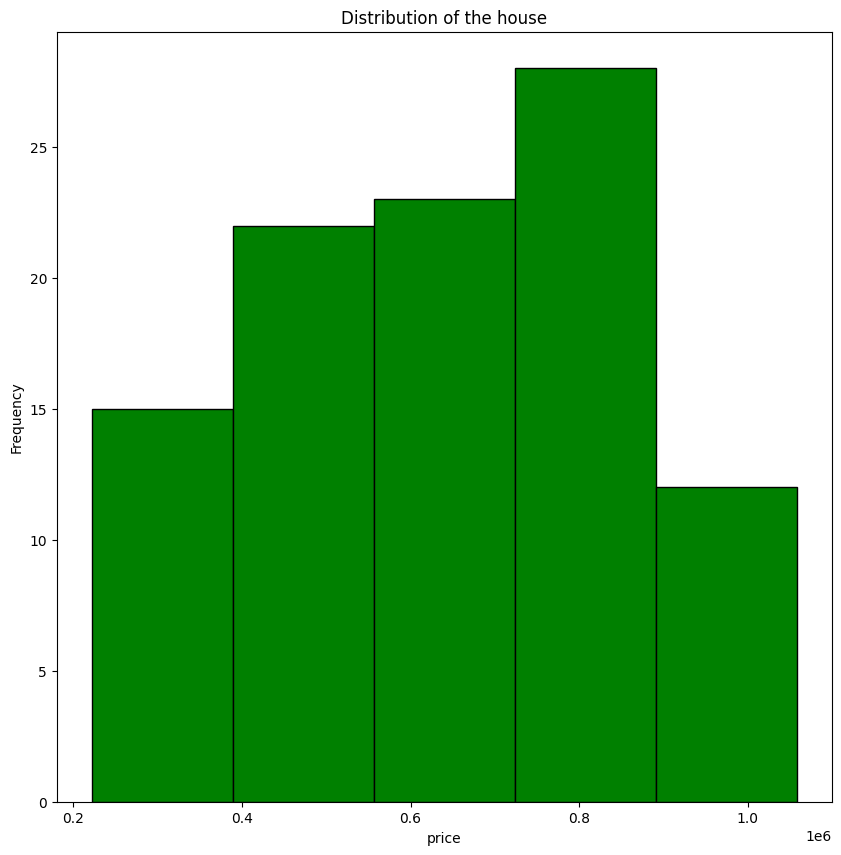

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.hist(df['price'], bins=5, color='green', edgecolor='black')
plt.title('Distribution of the house')
plt.xlabel('price')
plt.ylabel('Frequency')
plt.show()

,bedrooms,bathrooms,sqft_living,price
0,4,4,4913,959349
1,5,3,4248,893414
2,3,1,1163,383972
3,5,4,2498,691116
4,5,4,3945,892021


,bedrooms,bathrooms,sqft_living,price
count,100.000000,100.000000,100.000000,1.000000e+02
mean,3.070000,2.540000,3004.570000,6.414956e+05
std,1.401695,1.113916,1282.777339,2.044481e+05
min,1.000000,1.000000,598.000000,2.224030e+05
25%,2.000000,1.750000,2108.750000,4.819435e+05
50%,3.000000,3.000000,3294.000000,6.818180e+05
75%,4.000000,3.000000,4081.250000,7.840138e+05
max,5.000000,4.000000,4999.000000,1.057919e+06


,0
bedrooms,0
bathrooms,0
sqft_living,0
price,0


np.int64(0)

,price
price,1.000000
sqft_living,0.962880
bedrooms,0.226492
bathrooms,0.175133


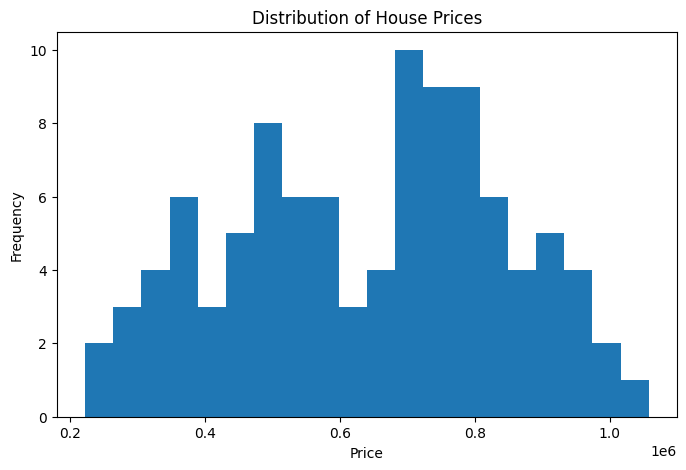

,Model,R2,Mae,RMSE
0,Linear Regression,0.981854,26666.362266,30666.413314
1,Ridge Regression,0.981857,26628.415640,30663.789104
2,Lasso Regression,0.981854,26666.178805,30666.352836


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Re-defining df, X, and y for independent execution of this cell
np.random.seed(42)

df = pd.DataFrame({
    'bedrooms': np.random.randint(1, 6, 100),
    'bathrooms': np.random.randint(1, 5, 100),
    'sqft_living': np.random.randint(500, 5000, 100),
})

df['price'] = (
    50000
    + df['bedrooms'] * 30000
    + df['bathrooms'] * 20000
    + df['sqft_living'] * 150
    + np.random.randint(-50000, 50000, 100)
)

# Ensure plt is imported correctly (was 'pl')
import matplotlib.pyplot as plt

display(df.head())
display(df.describe())
display(df.isnull().sum())
display(df.duplicated().sum())

corr = df.corr(numeric_only=True)
display(corr['price'].sort_values(ascending=False))

plt.figure(figsize=(8, 5))
plt.hist(df['price'], bins=20)
plt.title('Distribution of House Prices')
plt.xlabel('Price') # Corrected: xLabel to xlabel
plt.ylabel('Frequency') # Corrected: yLabel to ylabel
plt.show()

y = df['price'] # Corrected: 'Price' to 'price'
X = df.drop('price', axis=1)
X = X.select_dtypes(include=['int64', 'float64'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

linear_model = LinearRegression() # Renamed Linear to linear_model for consistency
ridge = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=1.0) # Renamed Lasso to lasso_model for consistency


linear_model.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test) # Corrected: Linear_pred to linear_pred
ridge_pred = ridge.predict(X_test)
lasso_pred = lasso_model.predict(X_test) # Corrected: Lasso_pred to lasso_pred


def evaluate_model(name, y_true, y_pred):
  return{
      "Model": name,
      "R2": r2_score(y_true, y_pred),
      "Mae": mean_absolute_error(y_true, y_pred),
      "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)) # Corrected: np.squrt to np.sqrt
  }

results = pd.DataFrame([
    evaluate_model("Linear Regression", y_test, linear_pred),
    evaluate_model("Ridge Regression", y_test, ridge_pred),
    evaluate_model("Lasso Regression", y_test, lasso_pred)
])
results